NAME : ARAVINDAN D

REG NO: 212223240012

In [1]:
import torch 
import torch.nn as nn
import torch.nn.functional as f
from torch.utils.data import DataLoader
from torchvision import datasets,transforms

In [2]:
import numpy as np
import pandas as pd
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

In [3]:
transform=transforms.ToTensor()

In [4]:
train_data=datasets.MNIST(root='../Data' , train=True ,download=True , transform=transform)

In [5]:
train_data

Dataset MNIST
    Number of datapoints: 60000
    Root location: ../Data
    Split: Train
    StandardTransform
Transform: ToTensor()

In [6]:
test_data=datasets.MNIST(root='../Data' , train=False ,download=True , transform=transform)

In [7]:
test_data

Dataset MNIST
    Number of datapoints: 10000
    Root location: ../Data
    Split: Test
    StandardTransform
Transform: ToTensor()

In [8]:
train_loader=DataLoader(train_data ,batch_size=10,shuffle=True)

In [9]:
test_loaader=DataLoader(test_data,batch_size=10,shuffle=False)

In [10]:
class ConvolutionalNetwork(nn.Module):

    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1,6,3,1)
        self.conv2 = nn.Conv2d(6,16,3,1)
        self.fc1 = nn.Linear(5*5*16,120)
        self.fc2 = nn.Linear(120,84)
        self.fc3 = nn.Linear(84,10)

    def forward(self, X):
        X = F.relu(self.conv1(X))
        X = F.max_pool2d(X, 2, 2)
        X = F.relu(self.conv2(X))
        X = F.max_pool2d(X, 2, 2)
        X = X.view(-1, 5*5*16)
        X = F.relu(self.fc1(X))
        X = F.relu(self.fc2(X))
        X = self.fc3(X)
        return F.log_softmax(X, dim=1)

In [11]:
torch.manual_seed(42)
model = ConvolutionalNetwork()
model

ConvolutionalNetwork(
  (conv1): Conv2d(1, 6, kernel_size=(3, 3), stride=(1, 1))
  (conv2): Conv2d(6, 16, kernel_size=(3, 3), stride=(1, 1))
  (fc1): Linear(in_features=400, out_features=120, bias=True)
  (fc2): Linear(in_features=120, out_features=84, bias=True)
  (fc3): Linear(in_features=84, out_features=10, bias=True)
)

In [12]:
for param in model.parameters():
    print(param.numel())

54
6
864
16
48000
120
10080
84
840
10


In [13]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [14]:
import time
import torch
import torch.nn.functional as F
from torch.utils.data import DataLoader

# Example: if you are using MNIST or any dataset
# Make sure dataset is already defined: train_data, test_data

train_loader = DataLoader(train_data, batch_size=64, shuffle=True)
test_loader = DataLoader(test_data, batch_size=64, shuffle=False)

start_time = time.time()

# Variables (Trackers)
epochs = 5
train_losses = []
test_losses = []
train_correct = []
test_correct = []

for i in range(epochs):

    trn_corr = 0
    tst_corr = 0

    # ---------------- TRAINING ----------------
    for b, (X_train, y_train) in enumerate(train_loader):

        # Forward pass
        y_pred = model(X_train)
        loss = criterion(y_pred, y_train)

        # Accuracy
        predicted = torch.max(y_pred.data, 1)[1]
        batch_corr = (predicted == y_train).sum()
        trn_corr += batch_corr

        # Backpropagation
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        if b % 600 == 0:
            print(f'Epoch: {i} Batch: {b} Loss: {loss.item()}')

    train_losses.append(loss.item())
    train_correct.append(trn_corr.item())

    # ---------------- TESTING ----------------
    with torch.no_grad():
        for b, (X_test, y_test) in enumerate(test_loader):

            y_val = model(X_test)

            predicted = torch.max(y_val.data, 1)[1]
            tst_corr += (predicted == y_test).sum()

        test_loss = criterion(y_val, y_test)

    test_losses.append(test_loss.item())
    test_correct.append(tst_corr.item())

# Time taken
current_time = time.time()
total = current_time - start_time
print(f'Training took {total/60:.2f} minutes')

Epoch: 0 Batch: 0 Loss: 2.3092453479766846
Epoch: 0 Batch: 600 Loss: 0.4150431454181671
Epoch: 1 Batch: 0 Loss: 0.06719569861888885
Epoch: 1 Batch: 600 Loss: 0.14904294908046722
Epoch: 2 Batch: 0 Loss: 0.06398304551839828
Epoch: 2 Batch: 600 Loss: 0.09705232828855515
Epoch: 3 Batch: 0 Loss: 0.04217991977930069
Epoch: 3 Batch: 600 Loss: 0.10087154805660248
Epoch: 4 Batch: 0 Loss: 0.018465669825673103
Epoch: 4 Batch: 600 Loss: 0.00756998872384429
Training took 4.00 minutes


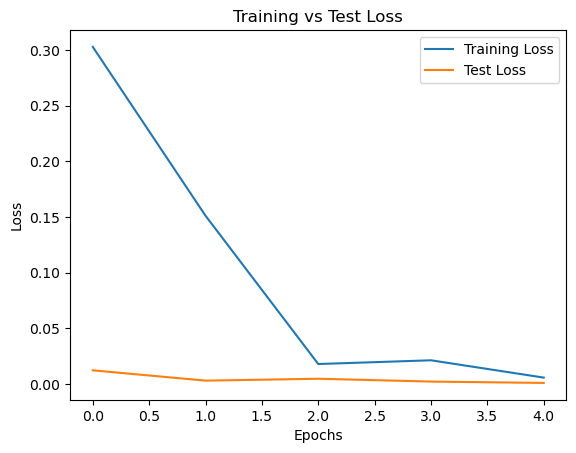

In [15]:
import matplotlib.pyplot as plt

# Directly plot (because values are already floats)
plt.plot(train_losses, label='Training Loss')
plt.plot(test_losses, label='Test Loss')

plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training vs Test Loss')
plt.legend()
plt.show()

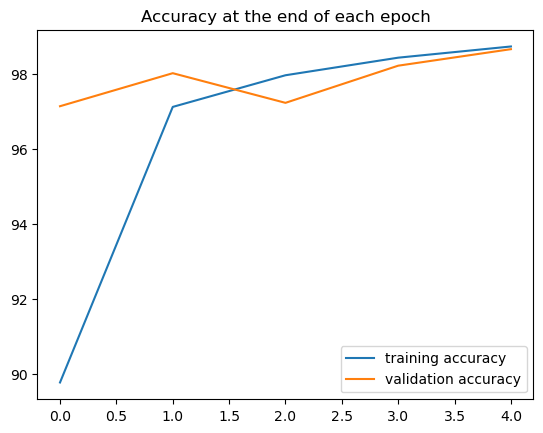

In [16]:
plt.plot([t/600 for t in train_correct], label='training accuracy')
plt.plot([t/100 for t in test_correct], label='validation accuracy')
plt.title('Accuracy at the end of each epoch')
plt.legend();
plt.show()

In [17]:
# Extract the data all at once, not in batches
test_load_all = DataLoader(test_data, batch_size=10000, shuffle=False)

In [18]:
with torch.no_grad():
    correct = 0
    for X_test, y_test in test_load_all:
        y_val = model(X_test)  # we don't flatten the data this time
        predicted = torch.max(y_val,1)[1]
        correct += (predicted == y_test).sum()


In [19]:
correct.item()

9865

In [20]:
correct.item()/len(test_data)

0.9865

In [21]:
# print a row of values for reference
np.set_printoptions(formatter=dict(int=lambda x: f'{x:4}'))
print(np.arange(10).reshape(1,10))
print()

# print the confusion matrix
print(confusion_matrix(predicted.view(-1), y_test.view(-1)))

[[   0    1    2    3    4    5    6    7    8    9]]

[[ 974    0    2    0    0    2    5    0    5    1]
 [   1 1134    2    1    1    1    2    6    0    3]
 [   0    1 1025    1    4    1    2   17    3    1]
 [   0    0    1 1004    0   12    0    4    3    4]
 [   0    0    1    0  967    0    1    0    0    3]
 [   0    0    0    2    0  869    1    0    0    2]
 [   4    0    0    0    1    5  946    0    0    0]
 [   1    0    1    0    1    1    0  995    1    2]
 [   0    0    0    2    0    0    1    2  960    2]
 [   0    0    0    0    8    1    0    4    2  991]]
